In [1]:
#딥러닝이론및응용 기말 Project
# 학번: 20215194 이름: 윤여산
# 모델: Dual-Head ResNet18 + 보수적 Augmentation (5-Fold, Style-Weighted Training)

#  1.라이브러리, Seed

import os           # 파일 경로 및 저장용
import random         # 랜덤 시드 제어

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2   # Tensor 변환용
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold   #  교차검증용 
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt
from tqdm.auto import tqdm


# randomness 제어를 위한 시드 고정 (학습 결과 재현을 위해 고정)
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
# 시드 값 선택
set_seed(42)
# 학습 장치 결정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
# 2. Paths & Data 로드
# 경로 설정 (kaggle 사용시)
root_dir = "/kaggle/input/2025-dl-final"
train_df = pd.read_csv(os.path.join(root_dir, "train.csv")) # 학습용 CSV 로드
test_df  = pd.read_csv(os.path.join(root_dir, "test.csv")) # 테스트용 CSV 로드

print(f"Train: {train_df.shape}, Test: {test_df.shape}") # 데이터 크기 확인
train_df.head(3) # 앞부분 샘플 확인 (출력)


Train: (2500, 5), Test: (10000, 2)


,filepath,is_ai,source,style,style_id
0,train/AI_LD_art_nouveau/0-260950338-624457.jpg,2,AI_LD,art_nouveau,0
1,train/AI_LD_art_nouveau/0-268898586-938022.jpg,2,AI_LD,art_nouveau,0
2,train/AI_LD_art_nouveau/0-277165415-252670.jpg,2,AI_LD,art_nouveau,0


In [3]:
## 3. 학습 때 사용할 transform 정의  (데이터 증강)
# 학습용 - 보수적 증강: 밝기/회전/대비/약간의 변형
train_tf = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.3),
    A.CLAHE(p=0.1),
])

## 평가용 transform 정의
# 검증/테스트용 - 단순 리사이즈
eval_tf = A.Compose([
    A.Resize(224,224)
])

# Normalize + Tensor 변환
# 데이터 분포로 확인해본 결과, 기본 제공 된 mean, std가 최적의 값이었음을 찾음
#이미지를 정규화 후, 평균·표준편차로 정규화하여 Tensor로 변환.
def normalize_and_tensor(img):
    img = img.astype(np.float32)/255.0
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = (img - mean)/std
    img = np.transpose(img, (2,0,1))
    return torch.tensor(img, dtype=torch.float32)


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
# 4. Dataset 정의
class ArtDataset(Dataset):
    #train/test 데이터프레임 기반의 커스텀 Dataset
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        # 1) 이미지 읽기
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(root_dir, row["filepath"])), cv2.COLOR_BGR2RGB)
        # 2) 증강 적용
        if self.transform: img = self.transform(image=img)["image"]
        # 3) 정규화 + 텐서 변환
        img_t = normalize_and_tensor(img)
        # 4) 라벨 로드
        y_source = torch.tensor(row["is_ai"], dtype=torch.long)
        y_style  = torch.tensor(row["style_id"], dtype=torch.long)
        return img_t, y_source, y_style


In [5]:
# 5. ResNet18 Backbone 구현
#Resnet에 쓸 기본 residual 블록 class
class BasicBlock(nn.Module):
    expansion=1
    def __init__(self,in_ch,out_ch,stride=1,downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,out_ch,3,stride,1,bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch,out_ch,3,1,1,bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.down  = downsample # shortcut 경로
    def forward(self,x):
        identity = x if self.down is None else self.down(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

#위 블록 이용하여 resnet18 간소화하여 
class ResNet18(nn.Module):
    def __init__(self,num_classes=512):
        super().__init__()
        self.in_ch=64
        # 초기 입력 계층
        self.conv1=nn.Conv2d(3,64,7,2,3,bias=False)
        self.bn1=nn.BatchNorm2d(64)
        self.relu=nn.ReLU(inplace=True)
        self.maxp=nn.MaxPool2d(3,2,1)
        # 4개 residual stage
        self.layer1=self._make_layer(64,2)
        self.layer2=self._make_layer(128,2,stride=2)
        self.layer3=self._make_layer(256,2,stride=2)
        self.layer4=self._make_layer(512,2,stride=2)
        self.avgp=nn.AdaptiveAvgPool2d((1,1))
        self.fc=nn.Linear(512,num_classes) # feature 추출
    
    def _make_layer(self,out_ch,blocks,stride=1):
        #블록 수만큼 Residual layer 생성
        down=None
        if stride!=1 or self.in_ch!=out_ch:
            down=nn.Sequential(
                nn.Conv2d(self.in_ch,out_ch,1,stride,bias=False),
                nn.BatchNorm2d(out_ch)
            )
        layers=[BasicBlock(self.in_ch,out_ch,stride,down)]
        self.in_ch=out_ch
        for _ in range(1,blocks):
            layers.append(BasicBlock(out_ch,out_ch))
        return nn.Sequential(*layers)
    
    def forward(self,x):
        x=self.relu(self.bn1(self.conv1(x)))
        x=self.maxp(x)
        x=self.layer1(x);
        x=self.layer2(x);
        x=self.layer3(x);
        x=self.layer4(x)
        x=self.avgp(x)
        return self.fc(torch.flatten(x,1))


In [6]:
# 6. Dual-Head 모델
# 두 개의 분류 헤드를 가진 ResNet 기반 모델
class DualHeadNet(nn.Module):
    def __init__(self,num_source=3,num_style=10):
        super().__init__()
        self.backbone = ResNet18(num_classes=512)
        self.head_source = nn.Linear(512,num_source) # source 분류용
        self.head_style  = nn.Linear(512,num_style) # style 분류용
    def forward(self,x):
        feat = self.backbone(x)
        return self.head_source(feat), self.head_style(feat)


In [7]:
# 7. Train 함수
def train_dual(model, train_loader, val_loader, epochs, save_path):
    opt = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    best_acc = 0

    # 기록용 리스트 추가
    train_src_accs, train_sty_accs, val_src_accs, val_sty_accs = [], [], [], []
    train_total_accs, val_total_accs = [], []
    train_losses, val_losses = [], []

    for e in range(epochs):
        # ---------------------- Train ----------------------
        model.train()
        tr_src_loss = tr_sty_loss = src_corr = sty_corr = 0
        for img, y_src, y_sty in train_loader:
            img, y_src, y_sty = img.to(device), y_src.to(device), y_sty.to(device)
            opt.zero_grad()
            out_src, out_sty = model(img)
            loss_src = loss_fn(out_src, y_src)
            loss_sty = loss_fn(out_sty, y_sty)
            loss = 0.4 * loss_src + 0.6 * loss_sty
            loss.backward()
            opt.step()

            tr_src_loss += loss_src.item() * img.size(0)
            tr_sty_loss += loss_sty.item() * img.size(0)
            src_corr += (out_src.argmax(1) == y_src).sum().item()
            sty_corr += (out_sty.argmax(1) == y_sty).sum().item()

        tr_src_acc = src_corr / len(train_loader.dataset)
        tr_sty_acc = sty_corr / len(train_loader.dataset)
        tr_total_acc = 0.3 * tr_src_acc + 0.7 * tr_sty_acc
        tr_loss = (0.4 * tr_src_loss + 0.6 * tr_sty_loss) / len(train_loader.dataset)

        # ---------------------- Validation ----------------------
        model.eval()
        src_corr = sty_corr = vl_src_loss = vl_sty_loss = 0
        with torch.no_grad():
            for img, y_src, y_sty in val_loader:
                img, y_src, y_sty = img.to(device), y_src.to(device), y_sty.to(device)
                out_src, out_sty = model(img)
                loss_src = loss_fn(out_src, y_src)
                loss_sty = loss_fn(out_sty, y_sty)
                vl_src_loss += loss_src.item() * img.size(0)
                vl_sty_loss += loss_sty.item() * img.size(0)
                src_corr += (out_src.argmax(1) == y_src).sum().item()
                sty_corr += (out_sty.argmax(1) == y_sty).sum().item()
        vl_src_acc = src_corr / len(val_loader.dataset)
        vl_sty_acc = sty_corr / len(val_loader.dataset)
        vl_total_acc = 0.3 * vl_src_acc + 0.7 * vl_sty_acc
        vl_loss = (0.4 * vl_src_loss + 0.6 * vl_sty_loss) / len(val_loader.dataset)

        # 로그 출력
        print(f"[Epoch {e+1:02d}/{epochs}] Train src_acc={tr_src_acc:.4f}, sty_acc={tr_sty_acc:.4f} | "
              f"Val src_acc={vl_src_acc:.4f}, sty_acc={vl_sty_acc:.4f}, total_acc={vl_total_acc:.4f}")

        # 기록
        train_src_accs.append(tr_src_acc)
        train_sty_accs.append(tr_sty_acc)
        val_src_accs.append(vl_src_acc)
        val_sty_accs.append(vl_sty_acc)
        train_total_accs.append(tr_total_acc)
        val_total_accs.append(vl_total_acc)
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)

        # 최고 성능 저장
        if vl_total_acc > best_acc:
            best_acc = vl_total_acc
            torch.save(model, save_path)
        sch.step()

    print(f"@@ Best Val Total Acc: {best_acc:.4f}")

    # 그래프용 결과 반환
    return {
        "train_loss": train_losses, "val_loss": val_losses,
        "train_total": train_total_accs, "val_total": val_total_accs,
        "best_acc": best_acc
    }


In [8]:
# 8. 5-Fold Cross Validation

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = []       # fold별 모델 경로
fold_accs = []         # fold별 최고 total acc
fold_histories = []    # fold별 학습 기록 (loss/acc 곡선용)

for fold, (tr_idx, vl_idx) in enumerate(folds.split(train_df, train_df["style_id"])):
    print(f"\n================ Fold {fold+1} ================")
    
    # 학습/검증 데이터 분할
    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    vl_df = train_df.iloc[vl_idx].reset_index(drop=True)
    
    # 데이터로더 생성
    train_loader = DataLoader(ArtDataset(tr_df, train_tf), batch_size=16, shuffle=True)
    val_loader   = DataLoader(ArtDataset(vl_df, eval_tf), batch_size=16, shuffle=False)
    
    # 모델 초기화
    model = DualHeadNet().to(device)
    save_path = f"/kaggle/working/dualhead_fold{fold+1}.pt"
    
    # 학습 및 기록 저장
    history = train_dual(model, train_loader, val_loader, epochs=40, save_path=save_path)
    best_models.append(save_path)
    fold_accs.append(history["best_acc"])
    fold_histories.append(history)

# ============================================================
# Fold별 결과 요약
# ============================================================
print("\n@@@ Fold별 성능 요약:")
for i, acc in enumerate(fold_accs):
    print(f"  Fold {i+1}: {acc:.4f}")
print(f"@@@ 평균 Total Acc: {np.mean(fold_accs):.4f}")



================ Fold 1 ================
[Epoch 01/40] Train src_acc=0.5780, sty_acc=0.2535 | Val src_acc=0.6420, sty_acc=0.3560, total_acc=0.4418
[Epoch 02/40] Train src_acc=0.6350, sty_acc=0.3345 | Val src_acc=0.6580, sty_acc=0.3620, total_acc=0.4508
[Epoch 03/40] Train src_acc=0.7080, sty_acc=0.3745 | Val src_acc=0.7500, sty_acc=0.3920, total_acc=0.4994
[Epoch 04/40] Train src_acc=0.7380, sty_acc=0.4035 | Val src_acc=0.7760, sty_acc=0.4700, total_acc=0.5618
[Epoch 05/40] Train src_acc=0.7655, sty_acc=0.4385 | Val src_acc=0.8300, sty_acc=0.4160, total_acc=0.5402
[Epoch 06/40] Train src_acc=0.7890, sty_acc=0.4385 | Val src_acc=0.8140, sty_acc=0.4340, total_acc=0.5480
[Epoch 07/40] Train src_acc=0.7890, sty_acc=0.4585 | Val src_acc=0.8240, sty_acc=0.4000, total_acc=0.5272
[Epoch 08/40] Train src_acc=0.8125, sty_acc=0.4800 | Val src_acc=0.8240, sty_acc=0.5140, total_acc=0.6070
[Epoch 09/40] Train src_acc=0.8210, sty_acc=0.4885 | Val src_acc=0.8420, sty_acc=0.4400, total_acc=0.5606
[Epo

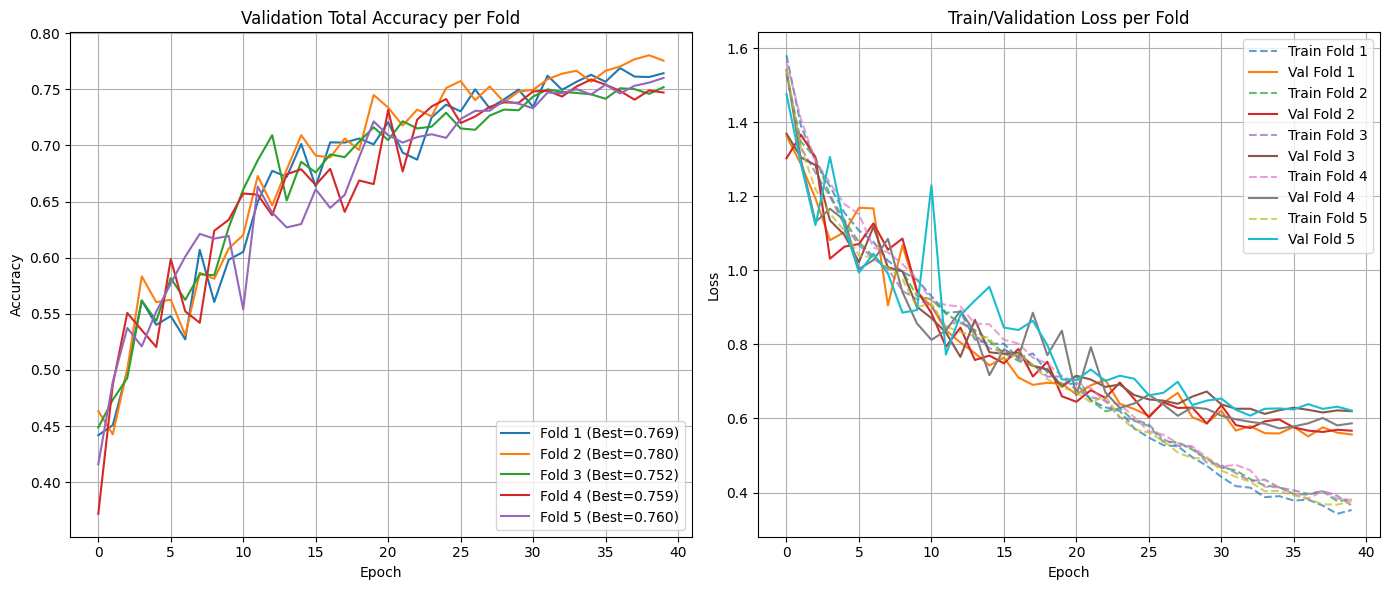

In [9]:
# Fold별 Loss & Accuracy 그래프 출력

plt.figure(figsize=(14,6))

# Accuracy
plt.subplot(1,2,1)
for i, hist in enumerate(fold_histories):
    plt.plot(hist["val_total"], label=f"Fold {i+1} (Best={hist['best_acc']:.3f})")
plt.title("Validation Total Accuracy per Fold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
for i, hist in enumerate(fold_histories):
    plt.plot(hist["train_loss"], '--', alpha=0.7, label=f"Train Fold {i+1}")
    plt.plot(hist["val_loss"], label=f"Val Fold {i+1}")
plt.title("Train/Validation Loss per Fold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# 9. Test Dataset & Inference (4-Fold 앙상블. Fold3 제외)

class TestDataset(Dataset):
    # 테스트 데이터셋 (레이블 없이 image_id, 이미지 반환)
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(root_dir, row["filepath"])), cv2.COLOR_BGR2RGB)
        if self.tf:
            img = self.tf(image=img)["image"]
        return row["image_id"], normalize_and_tensor(img)

# 테스트 데이터 로더 생성
test_loader = DataLoader(TestDataset(test_df, eval_tf), batch_size=32, shuffle=False)

# 안전한 모델 로드 (pickle 보안 대비)
import torch.serialization
torch.serialization.add_safe_globals([
    DualHeadNet, ResNet18, BasicBlock,
    nn.Conv2d, nn.BatchNorm2d, nn.ReLU, nn.Linear,
    nn.AdaptiveAvgPool2d, nn.MaxPool2d
])

# 저장된 fold별 모델 불러오기
models = []
exclude_fold = 3  # 제외할 fold 번호 (Fold 3)
for i, path in enumerate(best_models, start=1):
    if i == exclude_fold:
        print(f"@@@ Fold {i} 제외 (성능 낮음)")
        continue
    m = torch.load(path, map_location=device, weights_only=False)
    m.eval()
    models.append(m)
print(f" {len(models)}개 Fold 모델 로드 완료 (Fold {exclude_fold} 제외)")

# ------------------------------------------------------------
# 앙상블 예측 수행
# ------------------------------------------------------------
ids, src_preds, sty_preds = [], [], []
with torch.no_grad():
    for ids_batch, imgs in tqdm(test_loader, desc="[TEST ENSEMBLE - Fold3 제외]"):
        imgs = imgs.to(device)
        src_sum = torch.zeros((imgs.size(0), 3), device=device)
        sty_sum = torch.zeros((imgs.size(0), 10), device=device)
        # 각 fold 모델의 softmax 평균 앙상블
        for m in models:
            out_src, out_sty = m(imgs)
            src_sum += torch.softmax(out_src, dim=1)
            sty_sum += torch.softmax(out_sty, dim=1)
        src_sum /= len(models)
        sty_sum /= len(models)
        src_final = src_sum.argmax(1)
        sty_final = sty_sum.argmax(1)
        ids.extend(ids_batch)
        src_preds.extend(src_final.cpu().tolist())
        sty_preds.extend(sty_final.cpu().tolist())

# ------------------------------------------------------------
# 제출 파일 생성
# ------------------------------------------------------------
sub = pd.DataFrame({
    "image_id": [int(i) for i in ids],
    "is_ai": src_preds,
    "style_id": sty_preds
})
save_path = "/kaggle/working/submission_dualhead_kfold4_exclude3.csv"
sub.to_csv(save_path, index=False)
print(f"\n@@@ submission_dualhead_kfold4_exclude3.csv 생성 완료 ({save_path})")
sub.head(10)


@@@ Fold 3 제외 (성능 낮음)
 4개 Fold 모델 로드 완료 (Fold 3 제외)


[TEST ENSEMBLE - Fold3 제외]:   0%|          | 0/313 [00:00<?, ?it/s]


@@@ submission_dualhead_kfold4_exclude3.csv 생성 완료 (/kaggle/working/submission_dualhead_kfold4_exclude3.csv)


,image_id,is_ai,style_id
0,1,2,1
1,2,2,0
2,3,2,1
3,4,2,0
4,5,2,0
5,6,2,0
6,7,2,0
7,8,1,8
8,9,2,1
9,10,2,1
